In [1]:
# ================================
# AI TRAVEL ANALYST PROJECT
# FLIGHT PRICE PREDICTION
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib

from google.colab import files

print("Upload your flight pricing CSV file:")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Original dataset shape:", df.shape)
df.head()

Upload your flight pricing CSV file:


Saving flight_pricing_dataset.csv to flight_pricing_dataset.csv
Dataset loaded successfully!
Original dataset shape: (100000, 18)


,Flight_ID,Airline,Source,Destination,Departure_Date,Departure_Time,Arrival_Time,Duration,Total_Stops,Distance_km,Travel_Class,Days_Before_Departure,Season,Weekday,Aircraft_Type,Booking_Channel,Passenger_Count,Price
0,FL133547,Indigo,Hyderabad,Ahmedabad,2025-08-02,8:10 PM,21:50,1.67,0,910.5,Economy,43,Monsoon,Saturday,Boeing 737,Mobile App,5,5181.56
1,FL133458,AirAsia India,Pune,Mumbai,2025-06-05,12:10,12:55,0h 45m,non-stop,150,Economy,45,Monsoon,Thursday,ATR 72,Website,3,2000
2,FL173851,Qatar Airways,Sydney,PNQ,2025-02-11,5:05 PM,7:53 AM,14.80,1 stop,10168.1,Economy,3,NaN,Tuesday,Boeing 777,Mobile App,3,174762.69
3,FL101953,AirAsia India,Bangalore Airport,BOM,2025-04-19,07:05,10:16 AM,3h 11m,1,868.3,Economy,33,Summer,Saturday,Airbus A320,Mobile App,1,2846.09
4,FL162887,British Airways,Sydney,Goa,2026-07-05,10:40 PM,12:36,13.93,non-stop,10478.0,Economy,6,Monsoon,Sunday,Airbus A320,Website,2,145331.64


In [2]:
# ================================
# DATA CLEANING
# ================================

# Make a copy
df_clean = df.copy()

# Remove completely empty rows
df_clean = df_clean.dropna(how="all")

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Clean column names
df_clean.columns = df_clean.columns.str.strip()

# Convert Price to numeric
df_clean["Price"] = (
    df_clean["Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.strip()
)

df_clean["Price"] = pd.to_numeric(df_clean["Price"], errors="coerce")

# Numeric columns
numeric_columns = [
    "Price",
    "Distance_km",
    "Passenger_Count",
    "Days_Before_Departure",
    "Total_Stops",
    "Duration_Hours"
]

for col in numeric_columns:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Remove rows where target Price is missing
df_clean = df_clean.dropna(subset=["Price"])

# Remove impossible/invalid prices
df_clean = df_clean[df_clean["Price"] > 0]

# Fill numeric missing values
for col in numeric_columns:
    if col in df_clean.columns and col != "Price":
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill categorical missing values
categorical_columns = [
    "Airline",
    "Source",
    "Destination",
    "Travel_Class",
    "Season",
    "Weekday",
    "Aircraft_Type",
    "Booking_Channel"
]

for col in categorical_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype("object")
        df_clean[col] = df_clean[col].fillna("Unknown")
        df_clean[col] = df_clean[col].astype(str).str.strip()

print("Cleaning completed!")
print("Original dataset:", df.shape)
print("Cleaned dataset:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

Cleaning completed!
Original dataset: (100000, 18)
Cleaned dataset: (90258, 18)

Missing values:
Flight_ID                   0
Airline                     0
Source                      0
Destination                 0
Departure_Date           4472
Departure_Time           4427
Arrival_Time             4326
Duration                 4532
Total_Stops                 0
Distance_km                 0
Travel_Class                0
Days_Before_Departure       0
Season                      0
Weekday                     0
Aircraft_Type               0
Booking_Channel             0
Passenger_Count             0
Price                       0
dtype: int64


In [3]:
# ============================================
# FINAL CLEANING FOR MACHINE LEARNING
# ============================================

# Drop rows with missing date/time/duration information
required_columns = [
    "Departure_Date",
    "Departure_Time",
    "Arrival_Time",
    "Duration"
]

df_clean = df_clean.dropna(subset=required_columns)

print("Final dataset shape:", df_clean.shape)
print("\nMissing values after final cleaning:")
print(df_clean.isnull().sum())

Final dataset shape: (73787, 18)

Missing values after final cleaning:
Flight_ID                0
Airline                  0
Source                   0
Destination              0
Departure_Date           0
Departure_Time           0
Arrival_Time             0
Duration                 0
Total_Stops              0
Distance_km              0
Travel_Class             0
Days_Before_Departure    0
Season                   0
Weekday                  0
Aircraft_Type            0
Booking_Channel          0
Passenger_Count          0
Price                    0
dtype: int64


In [4]:
# ================================
# BASIC DATA ANALYSIS
# ================================

print("\n==============================")
print("AI TRAVEL ANALYST PROJECT")
print("==============================")

print("\nOriginal dataset shape:")
print(df.shape)

print("\nCleaned dataset shape:")
print(df_clean.shape)

print("\nAverage flight price:")
print(round(df_clean["Price"].mean(), 2))

print("\nMedian flight price:")
print(round(df_clean["Price"].median(), 2))

print("\nHighest flight price:")
print(round(df_clean["Price"].max(), 2))

print("\nLowest flight price:")
print(round(df_clean["Price"].min(), 2))


AI TRAVEL ANALYST PROJECT

Original dataset shape:
(100000, 18)

Cleaned dataset shape:
(73787, 18)

Average flight price:
73143.88

Median flight price:
49376.3

Highest flight price:
999306.03

Lowest flight price:
152.13


In [5]:
# ================================
# AVERAGE PRICE BY AIRLINE
# ================================

print("\nAverage price by airline:")

airline_prices = (
    df_clean.groupby("Airline")["Price"]
    .mean()
    .sort_values(ascending=False)
)

print(airline_prices)


Average price by airline:
Airline
SINGAPORE AIRLINES    111318.518506
BRITISH AIRWAYS       110081.803214
qatar airways         104010.462873
EMIRATES              103476.236220
singapore airlines    103184.724355
QATAR AIRWAYS         102906.473568
Qatar Airways         101335.434216
Etihad Airways        100802.635900
Thai Airways          100206.862245
Singapore Airlines    100124.530761
british airways       100072.510272
lufthansa             100011.043401
Emirates               99856.071182
THAI AIRWAYS           99808.770282
etihad airways         99513.973438
British Airways        99271.003359
Lufthansa              98959.929175
LUFTHANSA              98084.890027
ETIHAD AIRWAYS         96791.887745
thai airways           96437.710881
emirates               94143.017455
Unknown                74058.445194
vistara                52279.826351
air india              46974.359295
VISTARA                46468.209263
Air India              45346.621559
Vistara                45006.

In [6]:
# ================================
# AVERAGE PRICE BY TRAVEL CLASS
# ================================

print("\nAverage price by travel class:")

class_prices = (
    df_clean.groupby("Travel_Class")["Price"]
    .mean()
    .sort_values(ascending=False)
)

print(class_prices)


Average price by travel class:
Travel_Class
First              133647.687230
Business           115391.170892
Premium Economy     82177.996895
Unknown             75305.206109
Economy             59753.349920
Name: Price, dtype: float64


In [7]:
# ================================
# AVERAGE PRICE BY STOPS
# ================================

print("\nAverage price by number of stops:")

stop_prices = (
    df_clean.groupby("Total_Stops")["Price"]
    .mean()
    .sort_values(ascending=False)
)

print(stop_prices)


Average price by number of stops:
Total_Stops
2.0    85225.654554
1.0    75700.247525
0.0    61416.116306
Name: Price, dtype: float64


In [9]:
# ============================================
# CREATE DURATION_HOURS
# ============================================

def convert_duration(value):
    try:
        value = str(value).strip()

        # Already a numeric duration, e.g. 13.93 or 1.67
        if "h" not in value and "m" not in value:
            return float(value)

        # Format such as "3h 11m"
        hours = 0
        minutes = 0

        if "h" in value:
            hours = float(value.split("h")[0].strip())

        if "m" in value:
            minute_part = value.split("h")[-1]
            minutes = float(minute_part.replace("m", "").strip())

        return hours + (minutes / 60)

    except:
        return np.nan


df_clean["Duration_Hours"] = df_clean["Duration"].apply(convert_duration)

# Remove any rows where conversion failed
df_clean = df_clean.dropna(subset=["Duration_Hours"])

print("Duration conversion completed.")
print(df_clean[["Duration", "Duration_Hours"]].head(10))
print("\nMissing Duration_Hours:", df_clean["Duration_Hours"].isnull().sum())
print("\nFinal dataset shape:", df_clean.shape)

Duration conversion completed.
   Duration  Duration_Hours
0      1.67        1.670000
1    0h 45m        0.750000
2     14.80       14.800000
3    3h 11m        3.183333
4     13.93       13.930000
5   16h 47m       16.783333
6    1h 28m        1.466667
7    5h 27m        5.450000
8   17h 04m       17.066667
12   0h 59m        0.983333

Missing Duration_Hours: 0

Final dataset shape: (64071, 19)


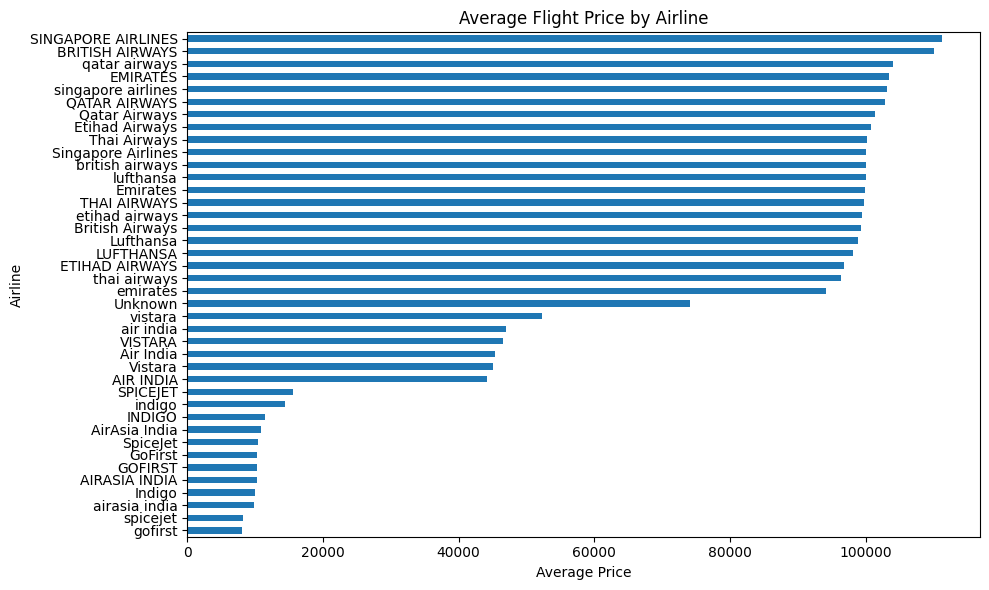

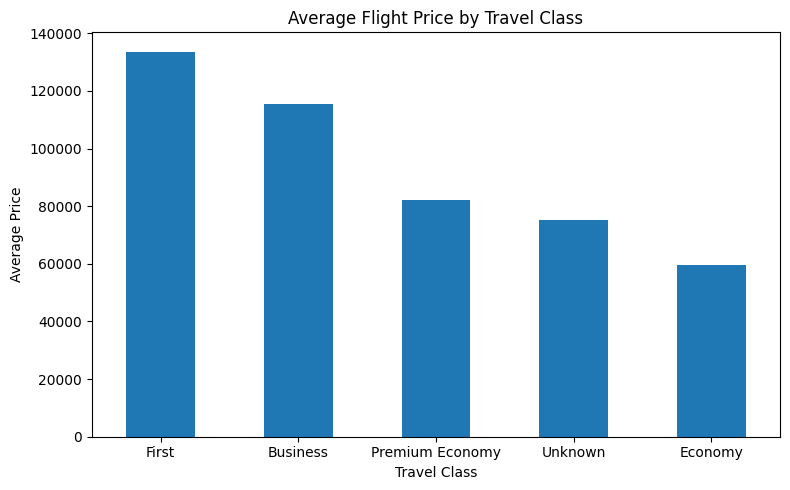

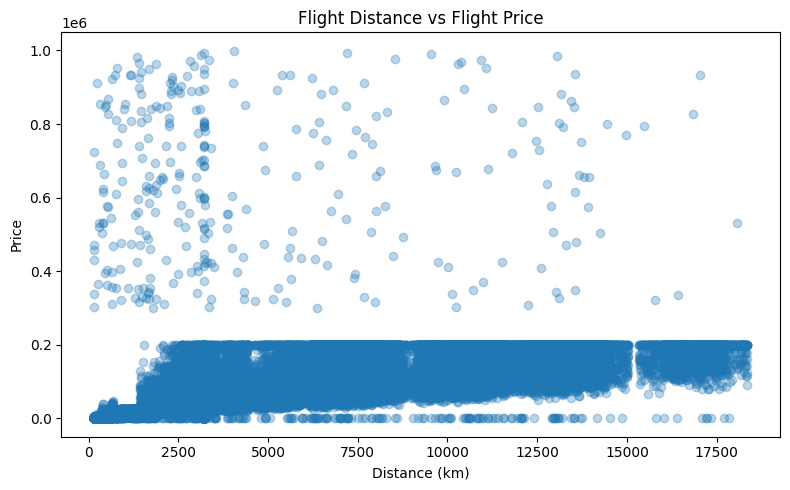

In [10]:
# ================================
# VISUALIZATION
# ================================

plt.figure(figsize=(10, 6))

airline_prices.sort_values().plot(kind="barh")

plt.title("Average Flight Price by Airline")
plt.xlabel("Average Price")
plt.ylabel("Airline")
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 5))

class_prices.plot(kind="bar")

plt.title("Average Flight Price by Travel Class")
plt.xlabel("Travel Class")
plt.ylabel("Average Price")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 5))

plt.scatter(
    df_clean["Distance_km"],
    df_clean["Price"],
    alpha=0.3
)

plt.title("Flight Distance vs Flight Price")
plt.xlabel("Distance (km)")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

In [12]:
# ==========================================
# CORRELATION ANALYSIS
# ==========================================

numeric_data = df_clean[
    [
        "Price",
        "Distance_km",
        "Passenger_Count",
        "Days_Before_Departure",
        "Total_Stops",
        "Duration_Hours"
    ]
]

print("\nCorrelation with Price:")

print(
    numeric_data.corr()["Price"]
    .sort_values(ascending=False)
)


Correlation with Price:
Price                    1.000000
Duration_Hours           0.671352
Distance_km              0.654532
Total_Stops              0.087700
Passenger_Count          0.003099
Days_Before_Departure   -0.100107
Name: Price, dtype: float64


In [13]:
# ==========================================
# MACHINE LEARNING
# FLIGHT PRICE PREDICTION
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features and target

X = df_clean.drop(columns=["Price", "Flight_ID"])
y = df_clean["Price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)

Features shape: (64071, 17)
Target shape: (64071,)

Training data: (51256, 17)
Testing data: (12815, 17)


In [11]:
# ================================
# MACHINE LEARNING DATA
# ================================

features = [
    "Airline",
    "Source",
    "Destination",
    "Travel_Class",
    "Season",
    "Weekday",
    "Aircraft_Type",
    "Booking_Channel",
    "Total_Stops",
    "Distance_km",
    "Days_Before_Departure",
    "Passenger_Count",
    "Duration_Hours"
]

X = df_clean[features]
y = df_clean["Price"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

print("\nTotal rows:", len(X))

Features:
           Airline             Source Destination Travel_Class   Season  \
0           Indigo          Hyderabad   Ahmedabad      Economy  Monsoon   
1    AirAsia India               Pune      Mumbai      Economy  Monsoon   
2    Qatar Airways             Sydney         PNQ      Economy  Unknown   
3    AirAsia India  Bangalore Airport         BOM      Economy   Summer   
4  British Airways             Sydney         Goa      Economy  Monsoon   

    Weekday Aircraft_Type Booking_Channel  Total_Stops  Distance_km  \
0  Saturday    Boeing 737      Mobile App          0.0        910.5   
1  Thursday        ATR 72         Website          1.0        150.0   
2   Tuesday    Boeing 777      Mobile App          1.0      10168.1   
3  Saturday   Airbus A320      Mobile App          1.0        868.3   
4    Sunday   Airbus A320         Website          1.0      10478.0   

   Days_Before_Departure  Passenger_Count  Duration_Hours  
0                   43.0              5.0        1.6

In [14]:
# ================================
# TRAIN TEST SPLIT
# ================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 51256
Testing rows: 12815


In [15]:
# ================================
# PREPROCESSING
# ================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

categorical_features = [
    "Airline",
    "Source",
    "Destination",
    "Travel_Class",
    "Season",
    "Weekday",
    "Aircraft_Type",
    "Booking_Channel"
]

numeric_features = [
    "Total_Stops",
    "Distance_km",
    "Days_Before_Departure",
    "Passenger_Count",
    "Duration_Hours"
]

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_pipeline, categorical_features),
        ("numeric", numeric_pipeline, numeric_features)
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [16]:
# ================================
# RANDOM FOREST MODEL
# ================================

from sklearn.ensemble import RandomForestRegressor

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=100,
                max_depth=15,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Training model...")

model.fit(X_train, y_train)

print("Model training completed successfully!")

Training model...
Model training completed successfully!


In [18]:
# ================================
# MODEL EVALUATION
# ================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("==============================")
print("MODEL PERFORMANCE")
print("==============================")

print("Mean Absolute Error:", round(mae, 2))
print("Root Mean Squared Error:", round(rmse, 2))
print("R2 Score:", round(r2, 4))

MODEL PERFORMANCE
Mean Absolute Error: 15718.65
Root Mean Squared Error: 49995.45
R2 Score: 0.5894


In [19]:
# ==========================================
# SAVE TRAINED MODEL
# ==========================================

import joblib

joblib.dump(model, "flight_price_prediction_model.pkl")

print("Model saved successfully!")
print("File: flight_price_prediction_model.pkl")

Model saved successfully!
File: flight_price_prediction_model.pkl


In [20]:
# ==========================================
# SAMPLE FLIGHT PRICE PREDICTION
# ==========================================

sample_flight = pd.DataFrame({
    "Airline": ["Indigo"],
    "Source": ["Hyderabad"],
    "Destination": ["Mumbai"],
    "Travel_Class": ["Economy"],
    "Season": ["Summer"],
    "Weekday": ["Monday"],
    "Aircraft_Type": ["Airbus A320"],
    "Booking_Channel": ["Website"],
    "Total_Stops": [1],
    "Distance_km": [700],
    "Days_Before_Departure": [30],
    "Passenger_Count": [2],
    "Duration_Hours": [2.0]
})

predicted_price = model.predict(sample_flight)[0]

print("==========================================")
print("FLIGHT PRICE PREDICTION")
print("==========================================")
print("Predicted Flight Price:", round(predicted_price, 2))
print("==========================================")

FLIGHT PRICE PREDICTION
Predicted Flight Price: 7205.26


In [21]:
# ==========================================
# FINAL PROJECT SUMMARY
# ==========================================

print("==========================================")
print("       AI TRAVEL ANALYST PROJECT")
print("       FLIGHT PRICE PREDICTION")
print("==========================================")

print("\nDATASET")
print("Original rows:", df.shape[0])
print("Original columns:", df.shape[1])
print("Final cleaned rows:", df_clean.shape[0])

print("\nMODEL")
print("Algorithm: Random Forest Regressor")
print("Number of trees: 100")
print("Maximum depth: 15")

print("\nMODEL PERFORMANCE")
print("Mean Absolute Error:", round(mae, 2))
print("Root Mean Squared Error:", round(rmse, 2))
print("R2 Score:", round(r2, 4))

print("\nSAMPLE PREDICTION")
print("Airline: Indigo")
print("Route: Hyderabad to Mumbai")
print("Class: Economy")
print("Distance: 700 km")
print("Predicted Price:", round(predicted_price, 2))

print("\n==========================================")
print("PROJECT COMPLETED SUCCESSFULLY!")
print("==========================================")

       AI TRAVEL ANALYST PROJECT
       FLIGHT PRICE PREDICTION

DATASET
Original rows: 100000
Original columns: 18
Final cleaned rows: 64071

MODEL
Algorithm: Random Forest Regressor
Number of trees: 100
Maximum depth: 15

MODEL PERFORMANCE
Mean Absolute Error: 15718.65
Root Mean Squared Error: 49995.45
R2 Score: 0.5894

SAMPLE PREDICTION
Airline: Indigo
Route: Hyderabad to Mumbai
Class: Economy
Distance: 700 km
Predicted Price: 7205.26

PROJECT COMPLETED SUCCESSFULLY!
